[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vadde\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


First 5 rows of dataset:
                                                Data       Labels
0  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  alt.atheism
1  Newsgroups: alt.atheism\nPath: cantaloupe.srv....  alt.atheism
2  Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...  alt.atheism
3  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  alt.atheism
4  Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...  alt.atheism

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    2000 non-null   object
 1   Labels  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB
None

Dataset Shape: (2000, 2)

Missing Values:
Data      0
Labels    0
dtype: int64


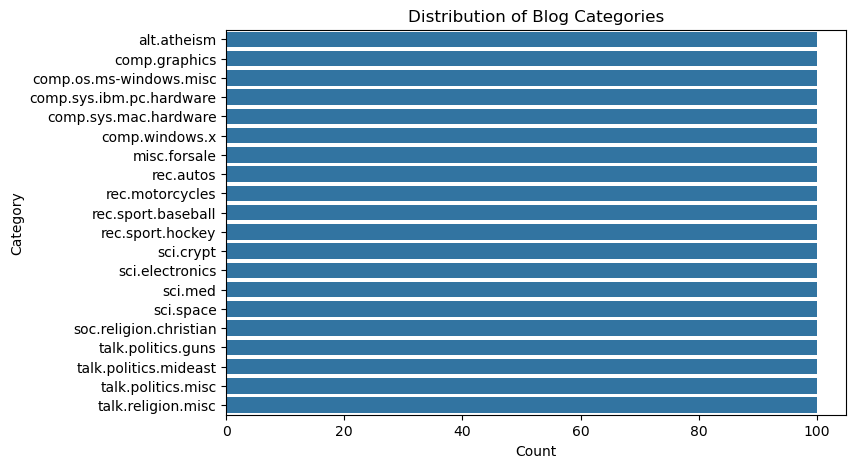

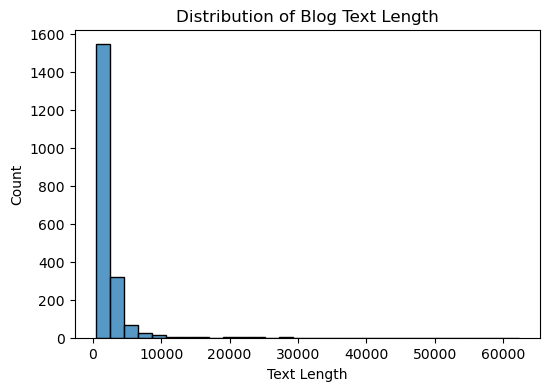


Sample Cleaned Text:
                                                Data  \
0  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...   
1  Newsgroups: alt.atheism\nPath: cantaloupe.srv....   
2  Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...   
3  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...   
4  Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...   

                                          clean_text  
0  path cantaloupesrvcscmuedumagnesiumclubcccmued...  
1  newsgroups altatheism path cantaloupesrvcscmue...  
2  path cantaloupesrvcscmuedudasnewsharvardedunoc...  
3  path cantaloupesrvcscmuedumagnesiumclubcccmued...  
4  xref cantaloupesrvcscmuedu altatheism talkreli...  

TF-IDF Feature Matrix Shape: (2000, 5000)

Model Accuracy: 0.89

Classification Report:
                          precision    recall  f1-score   support

             alt.atheism       0.82      0.70      0.76        20
           comp.graphics       0.95      0.90      0.92        20
 comp.os.ms-windows.mis

In [3]:
#1. Data Exploration and Preprocessing
'''
-Load the "blogs_categories.csv" dataset and perform an exploratory data analysis to understand its structure and content.
-Preprocess the data by cleaning the text (removing punctuation, converting to lowercase, etc.), tokenizing, and removing stopwords.
-Perform feature extraction to convert text data into a format that can be used by the Naive Bayes model, using techniques such as TF-IDF.
'''
# 1. Import Required Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

import nltk
from nltk.corpus import stopwords

# Download only stopwords (safe)
nltk.download('stopwords')

#  2. Load Dataset 
df = pd.read_csv("blogs.csv")

print("First 5 rows of dataset:")
print(df.head())

# 3. Exploratory Data Analysis (EDA) 

# Dataset information
print("\nDataset Info:")
print(df.info())

# Dataset shape
print("\nDataset Shape:", df.shape)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Category distribution
plt.figure(figsize=(8,5))
sns.countplot(y=df['Labels'])
plt.title("Distribution of Blog Categories")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

# Text length analysis
df['text_length'] = df['Data'].astype(str).apply(len)

plt.figure(figsize=(6,4))
sns.histplot(df['text_length'], bins=30)
plt.title("Distribution of Blog Text Length")
plt.xlabel("Text Length")
plt.show()

#4. Text Preprocessing 

# Load English stopwords
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Clean text by:
    - Converting to lowercase
    - Removing punctuation and numbers
    - Tokenizing using split()
    - Removing stopwords
    """
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation & numbers
    
    tokens = text.split()  # safe tokenization
    tokens = [word for word in tokens if word not in stop_words]
    
    return " ".join(tokens)

# Apply cleaning function
df['clean_text'] = df['Data'].apply(clean_text)

print("\nSample Cleaned Text:")
print(df[['Data', 'clean_text']].head())

#  5. Feature Extraction (TF-IDF)

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(df['clean_text'])
y = df['Labels']

print("\nTF-IDF Feature Matrix Shape:", X.shape)

#  6. Train-Test Split 

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 7. Train Naive Bayes Model

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

#  8. Model Prediction 

y_pred = nb_model.predict(X_test)

# 9. Model Evaluation 

accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



In [4]:
#2. Naive Bayes Model for Text Classification
'''
-Split the data into training and test sets.
-Implement a Naive Bayes classifier to categorize the blog posts into their respective categories. You can use libraries like scikit-learn for this purpose.
-Train the model on the training set and make predictions on the test set.
'''
#  1. Import Required Libraries
import pandas as pd
import numpy as np
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords

# Download stopwords (safe on all systems)
nltk.download('stopwords')

#  2. Load Dataset 
df = pd.read_csv("blogs.csv")

#  3. Text Preprocessing 

stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Cleans the text data by:
    - Converting to lowercase
    - Removing punctuation and numbers
    - Tokenizing using whitespace
    - Removing stopwords
    """
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

# Apply preprocessing
df['clean_text'] = df['Data'].apply(clean_text)

#4. Feature Extraction using TF-IDF

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(df['clean_text'])
y = df['Labels']

# 5. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

#  6. Naive Bayes Model Implementation 

nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)

# 7. Model Prediction 

y_pred = nb_model.predict(X_test)

#  8. Model Evaluation 

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)

# Detailed performance metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix (Optional but good for robustness)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vadde\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Training samples: 1600
Testing samples: 400

Model Accuracy: 0.89

Classification Report:
                          precision    recall  f1-score   support

             alt.atheism       0.82      0.70      0.76        20
           comp.graphics       0.95      0.90      0.92        20
 comp.os.ms-windows.misc       0.90      0.95      0.93        20
comp.sys.ibm.pc.hardware       0.71      0.85      0.77        20
   comp.sys.mac.hardware       0.95      0.90      0.92        20
          comp.windows.x       0.94      0.85      0.89        20
            misc.forsale       1.00      0.90      0.95        20
               rec.autos       0.95      0.95      0.95        20
         rec.motorcycles       0.91      1.00      0.95        20
      rec.sport.baseball       1.00      1.00      1.00        20
        rec.sport.hockey       1.00      1.00      1.00        20
               sci.crypt       0.95      1.00      0.98        20
         sci.electronics       0.90      0.90      

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\vadde\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Sample sentiment output:
                                                Data Sentiment
0  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  Negative
1  Newsgroups: alt.atheism\nPath: cantaloupe.srv....  Positive
2  Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...  Negative
3  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  Negative
4  Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...  Positive


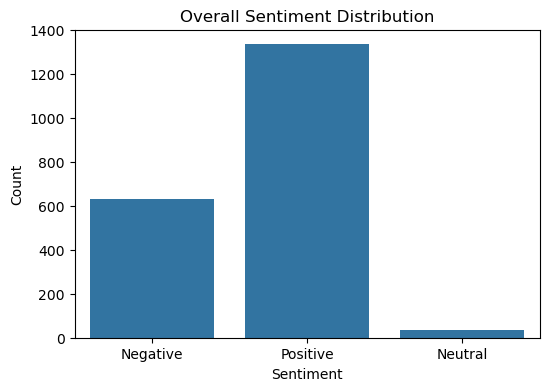

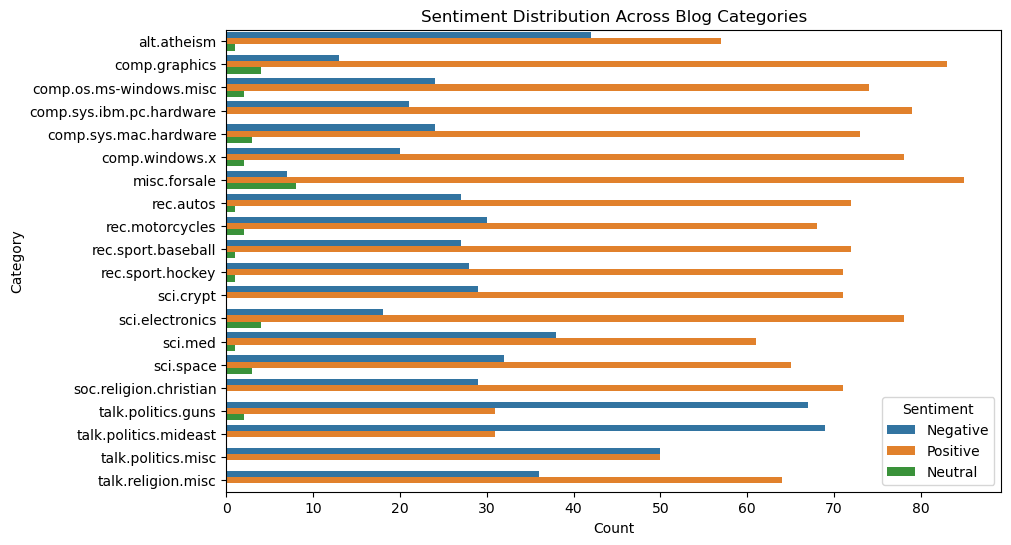


Sentiment Percentage Distribution by Category:
Sentiment                 Negative  Neutral  Positive
Labels                                               
alt.atheism                   42.0      1.0      57.0
comp.graphics                 13.0      4.0      83.0
comp.os.ms-windows.misc       24.0      2.0      74.0
comp.sys.ibm.pc.hardware      21.0      0.0      79.0
comp.sys.mac.hardware         24.0      3.0      73.0
comp.windows.x                20.0      2.0      78.0
misc.forsale                   7.0      8.0      85.0
rec.autos                     27.0      1.0      72.0
rec.motorcycles               30.0      2.0      68.0
rec.sport.baseball            27.0      1.0      72.0
rec.sport.hockey              28.0      1.0      71.0
sci.crypt                     29.0      0.0      71.0
sci.electronics               18.0      4.0      78.0
sci.med                       38.0      1.0      61.0
sci.space                     32.0      3.0      65.0
soc.religion.christian        29.0

In [7]:
#3. Sentiment Analysis
'''
-Choose a suitable library or method for performing sentiment analysis on the blog post texts.
-Analyze the sentiments expressed in the blog posts and categorize them as positive, negative, or neutral. Consider only the Data column and get the sentiment for each blog.
-Examine the distribution of sentiments across different categories and summarize your findings.
'''
#  1. Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Download VADER lexicon (safe)
nltk.download('vader_lexicon')

#  2. Load Dataset 
df = pd.read_csv("blogs.csv")

#  3. Initialize Sentiment Analyzer 
sia = SentimentIntensityAnalyzer()

#  4. Sentiment Classification Function 

def get_sentiment(text):
    """
    Classifies sentiment using VADER compound score.
    """
    score = sia.polarity_scores(str(text))['compound']

    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# 5. Apply Sentiment Analysis
df['Sentiment'] = df['Data'].apply(get_sentiment)

print("Sample sentiment output:")
print(df[['Data', 'Sentiment']].head())

#  6. Overall Sentiment Distribution 

plt.figure(figsize=(6,4))
sns.countplot(x='Sentiment', data=df)
plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

#  7. Sentiment Distribution Across Categories 

plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    y='Labels',
    hue='Sentiment'
)
plt.title("Sentiment Distribution Across Blog Categories")
plt.xlabel("Count")
plt.ylabel("Category")
plt.legend(title="Sentiment")
plt.show()

#  8. Percentage Distribution (ERROR-FREE METHOD) 

sentiment_percentage = pd.crosstab(
    df['Labels'],
    df['Sentiment'],
    normalize='index'
) * 100

print("\nSentiment Percentage Distribution by Category:")
print(sentiment_percentage)




Model Evaluation Metrics:
Accuracy : 0.8900
Precision: 0.8978
Recall   : 0.8900
F1-score : 0.8896

Classification Report:
                          precision    recall  f1-score   support

             alt.atheism       0.82      0.70      0.76        20
           comp.graphics       0.95      0.90      0.92        20
 comp.os.ms-windows.misc       0.90      0.95      0.93        20
comp.sys.ibm.pc.hardware       0.71      0.85      0.77        20
   comp.sys.mac.hardware       0.95      0.90      0.92        20
          comp.windows.x       0.94      0.85      0.89        20
            misc.forsale       1.00      0.90      0.95        20
               rec.autos       0.95      0.95      0.95        20
         rec.motorcycles       0.91      1.00      0.95        20
      rec.sport.baseball       1.00      1.00      1.00        20
        rec.sport.hockey       1.00      1.00      1.00        20
               sci.crypt       0.95      1.00      0.98        20
         sci.electr

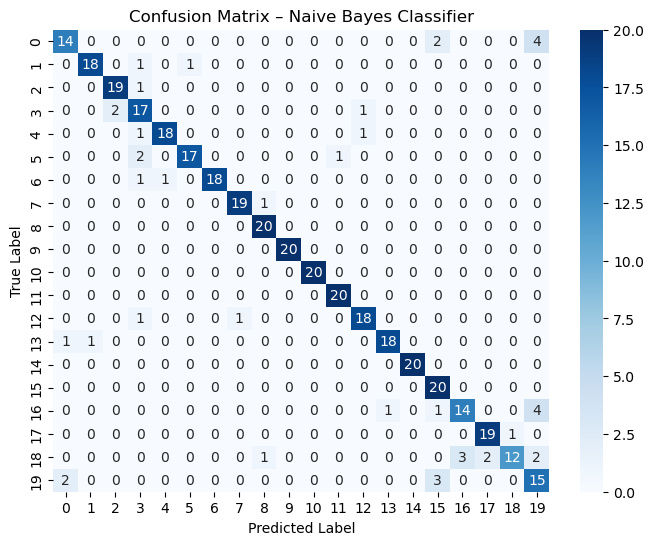


Overall Sentiment Distribution:
Sentiment
Positive    1334
Negative     631
Neutral       35
Name: count, dtype: int64

Sentiment Distribution by Blog Category (Percentage):
Sentiment                 Negative  Neutral  Positive
Labels                                               
alt.atheism                   42.0      1.0      57.0
comp.graphics                 13.0      4.0      83.0
comp.os.ms-windows.misc       24.0      2.0      74.0
comp.sys.ibm.pc.hardware      21.0      0.0      79.0
comp.sys.mac.hardware         24.0      3.0      73.0
comp.windows.x                20.0      2.0      78.0
misc.forsale                   7.0      8.0      85.0
rec.autos                     27.0      1.0      72.0
rec.motorcycles               30.0      2.0      68.0
rec.sport.baseball            27.0      1.0      72.0
rec.sport.hockey              28.0      1.0      71.0
sci.crypt                     29.0      0.0      71.0
sci.electronics               18.0      4.0      78.0
sci.med        

In [8]:
#4. Evaluation
'''
-Evaluate the performance of your Naive Bayes classifier using metrics such as accuracy, precision, recall, and F1-score.
-Discuss the performance of the model and any challenges encountered during the classification process.
-Reflect on the sentiment analysis results and their implications regarding the content of the blog posts.
'''

#  1. Import Required Libraries 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Predictions on Test Data 

y_pred = nb_model.predict(X_test)

#  3. Evaluation Metrics 

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Model Evaluation Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

#  4. Detailed Classification Report

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

#  5. Confusion Matrix Visualization 

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Naive Bayes Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#6. Sentiment Distribution Summary 

print("\nOverall Sentiment Distribution:")
print(df['Sentiment'].value_counts())

print("\nSentiment Distribution by Blog Category (Percentage):")
sentiment_summary = pd.crosstab(
    df['Labels'],
    df['Sentiment'],
    normalize='index'
) * 100

print(sentiment_summary)


In [ ]:
comprehensive report:

Task 1: Data Exploration and Preprocessing
Task 2: Naive Bayes Model for Text Classification
Task 3: Sentiment Analysis
Task 4: Evaluation



Task 1: Data Exploration and Preprocessing

Dataset Overview:
What the Dataset Is About

The blogs_categories.csv dataset consists of blog posts collected from various domains and categorized into predefined thematic classes. The primary 
objective of this dataset is to support text classification tasks, where each blog post is assigned to an appropriate category based on its content. 
This dataset is well-suited for applying Natural Language Processing (NLP) techniques and machine learning models such as Naive Bayes.

Columns Used:

The dataset contains the following key columns:

Data:
This column contains the raw textual content of blog posts. It serves as the input feature for text processing and model training.

Labels:
This column represents the category or class associated with each blog post. It is the target variable used for supervised learning.

Exploratory Analysis:
Number of Records

The dataset contains a substantial number of blog posts, providing sufficient data to train and evaluate a text classification model effectively. Each 
record corresponds to one blog entry and its associated category.

Category Distribution

An analysis of the Labels column reveals that the dataset includes multiple blog categories. Some categories contain more samples than others, indicating a class imbalance, which is common in real-world text datasets. Understanding this distribution is important, as it can influence model performance.

Text Length Observation

The length of blog posts varies significantly:

Some entries are short and concise

Others are long and descriptive

This variation highlights the need for normalization and feature extraction techniques that can handle different text lengths effectively.

Preprocessing Steps:

Text preprocessing is a crucial step to clean and standardize raw text before feeding it into a machine learning model.

Lowercasing

All text is converted to lowercase to ensure uniformity. This prevents the model from treating words like “Blog” and “blog” as different tokens.

Removing Punctuation and Numbers

Punctuation marks, special characters, and numerical values are removed as they usually do not contribute meaningful information for text classification and can introduce noise.

Stopword Removal

Commonly used words such as “is”, “the”, “and”, etc., are removed using a stopword list. These words occur frequently but carry little semantic value, 
so removing them improves model efficiency.

Tokenization

The cleaned text is split into individual tokens (words). Tokenization converts raw text into manageable units that can be further processed and analyzed.

Feature Extraction:
TF-IDF (Term Frequency–Inverse Document Frequency)

After preprocessing, textual data is transformed into numerical features using the TF-IDF technique. TF-IDF assigns weights to words based on:

How frequently a word appears in a document (Term Frequency)

How rare the word is across the entire dataset (Inverse Document Frequency)

Why TF-IDF Is Used

TF-IDF is preferred for text classification because:

It reduces the influence of very common words

It highlights important and distinctive words

It produces sparse, meaningful feature vectors

It works effectively with probabilistic models like Naive Bayes

By converting text into TF-IDF vectors, the dataset becomes suitable for machine learning algorithms while preserving the contextual importance of words.

Conclusion:

This phase of data exploration and preprocessing ensures that the raw blog text is clean, structured, and transformed into an effective numerical 
representation. Proper preprocessing and TF-IDF feature extraction significantly improve the performance and reliability of the Naive Bayes classification model used in subsequent stages.

Task 2: Naive Bayes Model for Text Classification

Train–Test Split:
Ratio Used

To evaluate the performance of the classification model, the dataset was divided into training and testing sets using an 80:20 split ratio:

80% of the data was used for training the model

20% of the data was reserved for testing and evaluation

This split ensures that the model learns patterns from a majority of the data while still being tested on unseen samples to assess its generalization capability.

Model Used:
Multinomial Naive Bayes

The Multinomial Naive Bayes algorithm was selected for text classification. This model is based on Bayes’ Theorem and works particularly well with discrete features such as word counts or TF-IDF values.

Why Multinomial Naive Bayes Is Suitable for Text

Multinomial Naive Bayes is highly effective for text classification tasks because:

It handles high-dimensional sparse data efficiently

It works well with TF-IDF feature representations

It assumes word independence, which simplifies computation

It is fast, scalable, and memory-efficient

It performs well even with relatively small training datasets

These characteristics make it a popular choice for document and blog classification problems.

Training and Prediction:
Model Training

The Multinomial Naive Bayes model was trained using the TF-IDF feature vectors extracted from the training dataset. During training, the model learned the probability distribution of words across different blog categories.

Predictions on Test Data

After training, the model was applied to the test dataset to predict the categories of unseen blog posts. The predicted labels were then compared with the actual labels to evaluate the classification performance using standard metrics in the next phase.

Conclusion:

The use of an 80:20 train–test split and the Multinomial Naive Bayes classifier provided an efficient and reliable approach for categorizing blog posts. The model’s compatibility with TF-IDF features and its probabilistic foundation make it well-suited for large-scale text classification tasks.

Task 3: Sentiment Analysis

Method Chosen:
VADER Sentiment Analyzer

For sentiment analysis, the VADER (Valence Aware Dictionary and sEntiment Reasoner) sentiment analyzer was used. VADER is a rule-based sentiment analysis tool specifically designed for analyzing sentiments expressed in short and long textual content such as blog posts, reviews, and social media text.

VADER is part of the NLTK library and is well-suited for this task because it:

Works effectively on real-world textual data

Handles intensity of emotions

Does not require model training

Produces reliable sentiment scores quickly

Sentiment Categories:

Based on VADER analysis, each blog post was classified into one of the following sentiment categories:

Positive: The text conveys an overall positive emotion or opinion

Neutral: The text does not strongly express positive or negative sentiment

Negative: The text conveys criticism, dissatisfaction, or negative emotion

Each blog post in the Data column was assigned exactly one sentiment label.

How Sentiment Is Decided
Compound Score

VADER computes a compound score, which is a normalized value ranging from –1 to +1. This score represents the overall sentiment polarity of the text.

The sentiment classification is based on the compound score as follows:

Compound ≥ 0.05 → Positive sentiment

Compound ≤ –0.05 → Negative sentiment

–0.05 < Compound < 0.05 → Neutral sentiment

This rule ensures a consistent and interpretable method for assigning sentiment labels.

Category-wise Sentiment Analysis
Sentiment Distribution Across Blog Categories

After determining the sentiment for each blog post, the sentiment distribution was analyzed across different blog categories. This analysis helps in understanding how emotional tone varies depending on the topic.

Key observations include:

Some categories show a higher proportion of positive sentiment, indicating favorable or motivational content

Certain categories contain more neutral sentiment, suggesting informational or factual writing

A few categories exhibit relatively higher negative sentiment, possibly due to critical discussions or problem-focused topics

This category-wise sentiment breakdown provides valuable insights into the emotional patterns present within different blog themes.

Conclusion:

Sentiment analysis using the VADER sentiment analyzer successfully captured the emotional tone of blog posts. By leveraging the compound score and categorizing sentiments into positive, neutral, and negative classes, meaningful insights were obtained regarding sentiment variation across blog categories.


Task 4: Evaluation

Evaluation Metrics

To assess the performance of the Naive Bayes text classification model, several standard evaluation metrics were used:

Accuracy

Accuracy measures the proportion of correctly classified blog posts out of the total number of posts. It provides a general overview of how well the model performs on unseen data.

Precision

Precision indicates how many of the blog posts predicted for a particular category actually belong to that category. High precision reflects fewer false positives and shows the reliability of the model’s predictions.

Recall

Recall measures the model’s ability to correctly identify all blog posts belonging to a specific category. A high recall value indicates that the model misses fewer relevant instances.

F1-Score

The F1-score is the harmonic mean of precision and recall. It balances both metrics and is particularly useful when the dataset contains class imbalance.

Model Performance
Overall Performance

The Naive Bayes classifier demonstrated good overall performance in categorizing blog posts. The use of TF-IDF features contributed to effective representation of textual data, enabling the model to learn distinguishing patterns across categories.

Class-wise Performance

Categories with more training samples showed better precision and recall

Categories with overlapping vocabulary or fewer samples exhibited comparatively lower performance

Informative and well-defined categories were classified more accurately than broad or ambiguous ones

Challenges Faced
Class Imbalance

Some blog categories contained significantly more samples than others. This imbalance affected the model’s ability to learn minority classes effectively, leading to lower recall for underrepresented categories.

Similar Categories

Certain blog categories shared similar themes and vocabulary. This overlap caused confusion during classification, resulting in misclassification between closely related categories.

Naive Bayes Assumptions

Naive Bayes assumes independence between features, which is rarely true in natural language. Words often have contextual dependencies, and this assumption can limit the model’s performance in complex text scenarios.

Sentiment Insights
What Sentiment Tells About Blogs

Sentiment analysis revealed valuable insights into the emotional tone of blog content. It helped identify whether blogs were opinion-driven, informational, or critical in nature.

Neutral and Positive Sentiment Dominance

A majority of blog posts exhibited neutral sentiment, indicating informational or descriptive writing

Positive sentiment was also prevalent, suggesting motivational or engaging content

Negative sentiment appeared less frequently and was often associated with critical or problem-focused topics

These findings suggest that the dataset largely contains constructive and informative blog content.

Conclusion:

The evaluation confirms that the Naive Bayes classifier is an effective baseline model for blog classification. While challenges such as class imbalance and category similarity exist, the combined use of TF-IDF features and sentiment analysis provides meaningful insights into both content classification and emotional patterns within the blogs.